# Model Evaluation on External Datasets

This notebook evaluates the three trained models (GNN, 1D CNN, 2D CNN) on external datasets (ov, uv, lit_uv) using both validation and test splits. We compute unnormalized metrics (dH, Tm, dG₃₇).

In [1]:
import os
import json
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import r2_score

# Setup
sns.set_style("darkgrid")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Load Dataset and Compute Statistics

In [2]:
DATA_ROOT = './data/models'
RAW_DIR = os.path.join(DATA_ROOT, 'raw')

# Load main dataset and splits
df = pd.read_csv(os.path.join(RAW_DIR, 'combined_dataset.csv'), index_col='SEQID')
df.sort_index(inplace=True)

with open(os.path.join(RAW_DIR, 'combined_data_split.json')) as f:
    split_dict = json.load(f)

# Calculate normalization statistics from training set
def calc_sumstats(df):
    """Compute min/max for dH and Tm from a dataframe."""
    return {
        'dH_min': np.min(df.dH), 'dH_max': np.max(df.dH),
        'Tm_min': np.min(df.Tm), 'Tm_max': np.max(df.Tm)
    }

def normalize(val, vmin, vmax):
    return (val - vmin) / (vmax - vmin)

def unnormalize(val, vmin, vmax):
    return val * (vmax - vmin) + vmin

train_df = df.loc[df.index.isin(split_dict['train_ind'])]
stats = calc_sumstats(train_df)

print('Training set normalization stats:')
for key, val in stats.items():
    print(f"  {key}: {val:.4f}")

print(f'\nDataset splits:')
for ds in ['ov', 'uv', 'lit_uv']:
    sub = df[df['dataset']==ds]
    print(f'\n{ds}: {len(sub)} total')
    for s_name in ['val', 'test']:
        cnt = len(sub[sub.index.isin(split_dict[s_name+'_ind'])])
        if cnt > 0: 
            print(f'  {s_name}: {cnt}')

Training set normalization stats:
  dH_min: -68.2045
  dH_max: -2.7024
  Tm_min: 13.6475
  Tm_max: 68.6359

Dataset splits:

ov: 2775 total
  val: 1387
  test: 1388

uv: 19 total
  val: 10
  test: 9

lit_uv: 348 total
  val: 174
  test: 174


## 2. Load GNN Model

In [3]:
from torch.nn import Linear, ModuleList
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, Set2Set

# GNN encoding functions
def onehot_nucleotide(seq_str: str) -> np.ndarray:
    """One-hot encode a DNA sequence."""
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    N = len(seq_str)
    arr = np.zeros((N, 4), dtype=np.float32)
    for i, nt in enumerate(seq_str.upper()):
        arr[i, mapping[nt]] = 1.0
    return arr

def dotbracket_to_edges(struct: str):
    """Convert dot-bracket notation to edge list + edge features."""
    N = len(struct)
    strand_break = struct.find('+')
    
    if strand_break == -1:
        backbone = [[i, i+1] for i in range(N - 1)]
    else:
        struct = struct.replace('+', '')
        N -= 1
        backbone = [[i, i+1] for i in range(N - 1)
                    if i != strand_break - 1 and i + 1 != strand_break]
    
    hbonds = []
    flag3p = N - 1
    for i, ch in enumerate(struct):
        if ch == '(':
            for j in range(flag3p, i, -1):
                if struct[j] == ')':
                    hbonds.append([i, j])
                    flag3p = j - 1
                    break
    
    edges = (backbone + [e[::-1] for e in backbone] + 
             hbonds + [e[::-1] for e in hbonds])
    
    n_bb, n_hb = len(backbone), len(hbonds)
    edge_attr = np.zeros((len(edges), 3), dtype=np.float32)
    edge_attr[:n_bb, 0] = 1
    edge_attr[n_bb:2*n_bb, 1] = 1
    edge_attr[2*n_bb:, 2] = 1
    
    edge_index = torch.tensor(np.array(edges).T, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return edge_index, edge_attr

def row_to_graph(row, stats):
    """Convert row to graph for GNN."""
    reference_sequence = row['RefSeq']
    if isinstance(reference_sequence, list):
        reference_sequence = ''.join(reference_sequence)
    elif isinstance(reference_sequence, str) and '[' in reference_sequence:
        reference_sequence = ''.join(eval(reference_sequence))

    x = torch.tensor(onehot_nucleotide(reference_sequence), dtype=torch.float)
    edge_index, edge_attr = dotbracket_to_edges(row['TargetStruct'])
    
    dH_norm = normalize(row.dH, stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row.Tm, stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# GNN Model Definition
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels=125, n_conv_layers=4,
                 linear_hidden=128, conv_dropout=0.0127,
                 linear_dropout=0.25, set2set_steps=10):
        super().__init__()
        torch.manual_seed(12345)
        
        self.conv_dropout = conv_dropout
        self.linear_dropout = linear_dropout
        
        self.convs = ModuleList()
        self.convs.append(
            TransformerConv(4, hidden_channels, heads=1,
                            edge_dim=3, dropout=conv_dropout)
        )
        
        for _ in range(n_conv_layers - 1):
            self.convs.append(
                TransformerConv(hidden_channels, hidden_channels, heads=1,
                                edge_dim=3, dropout=conv_dropout)
            )
        
        self.pool = Set2Set(hidden_channels, processing_steps=set2set_steps)
        
        self.lin1 = Linear(2 * hidden_channels, linear_hidden)
        self.lin2 = Linear(linear_hidden, linear_hidden)
        self.lin3 = Linear(linear_hidden, 2)
    
    def forward(self, x, edge_index, edge_attr, batch):
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr)
            x = F.leaky_relu(x)
            x = F.dropout(x, p=self.conv_dropout, training=self.training)
        
        x = self.pool(x, batch)
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.linear_dropout, training=self.training)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        
        return torch.flatten(x)

# Load latest GNN model
gnn_model_dir = sorted(glob('MyExperiments/GNN/models/*/'))[-1]
gnn_model = GNN()
gnn_model.load_state_dict(torch.load(os.path.join(gnn_model_dir, 'model.pt'), map_location=device))
gnn_model = gnn_model.to(device)
gnn_model.eval()

print(f'Loaded GNN model from {gnn_model_dir}')
print(f'  Parameters: {sum(p.numel() for p in gnn_model.parameters()):,}')

Loaded GNN model from MyExperiments/GNN/models/GNN_20260302_030601/
  Parameters: 430,398


## 3. Load 1D CNN Model

In [4]:
MAX_SEQ_LEN = 24

# 1D CNN encoding functions
def encode_sequence_1d(seq_str: str) -> np.ndarray:
    mapping = {'A': 0, 'T': 1, 'C': 2, 'G': 3}
    arr = np.zeros((len(seq_str), 4), dtype=np.float32)
    for i, nt in enumerate(seq_str.upper()):
        arr[i, mapping[nt]] = 1.0
    return arr

def encode_structure_1d(struct_str: str) -> np.ndarray:
    struct_clean = struct_str.replace('+', '')
    arr = np.zeros((len(struct_clean), 3), dtype=np.float32)
    for i, ch in enumerate(struct_clean):
        if ch == '(':
            arr[i, 0] = 1.0
        elif ch == ')':
            arr[i, 1] = 1.0
        elif ch == '.':
            arr[i, 2] = 1.0
    return arr

def encode_row_1d_cnn(row, stats, max_len=MAX_SEQ_LEN):
    refseq = row['RefSeq']
    if isinstance(refseq, list):
        refseq = ''.join(refseq)
    elif isinstance(refseq, str) and '[' in refseq:
        refseq = ''.join(eval(refseq))
    
    seq_enc = encode_sequence_1d(refseq)
    struct_enc = encode_structure_1d(row['TargetStruct'])
    features = np.concatenate([seq_enc, struct_enc], axis=1)
    
    padded = np.zeros((max_len, 7), dtype=np.float32)
    padded[:features.shape[0]] = features
    x = torch.tensor(padded.T, dtype=torch.float)
    
    dH_norm = normalize(row.dH, stats['dH_min'], stats['dH_max'])
    Tm_norm = normalize(row.Tm, stats['Tm_min'], stats['Tm_max'])
    y = torch.tensor([dH_norm, Tm_norm], dtype=torch.float)
    
    return x, y

# 1D CNN Model Definition
class DNA_CNN(torch.nn.Module):
    def __init__(self, in_channels=7, dropout=0.2):
        super().__init__()
        torch.manual_seed(12345)
        self.conv_block = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(64, 128, kernel_size=3, padding=1),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(128, 128, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Conv1d(128, 128, kernel_size=5, padding=2),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
        )
        self.global_pool = torch.nn.AdaptiveAvgPool1d(1)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.head(x)

# Load latest 1D CNN model
cnn1d_model_dir = sorted(glob('MyExperiments/1DCNN/models/*/'))[-1]
cnn1d_model = DNA_CNN()
cnn1d_model.load_state_dict(torch.load(os.path.join(cnn1d_model_dir, 'model.pt'), map_location=device))
cnn1d_model = cnn1d_model.to(device)
cnn1d_model.eval()

print(f'Loaded 1D CNN model from {cnn1d_model_dir}')
print(f'  Parameters: {sum(p.numel() for p in cnn1d_model.parameters()):,}')

Loaded 1D CNN model from MyExperiments/1DCNN/models/1DCNN_20260302_013044/
  Parameters: 199,490


## 4. Load 2D CNN Model

In [ ]:
# 2D CNN Model Definition
class CNN2D(torch.nn.Module):
    def __init__(self, in_channels=6, dropout=0.2):
        super().__init__()
        torch.manual_seed(12345)
        self.conv_block = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 64, kernel_size=(3, 3), padding=(1, 1)),
            torch.nn.BatchNorm2d(64),
            torch.nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            torch.nn.BatchNorm2d(128),
            torch.nn.Conv2d(128, 128, kernel_size=(3, 5), padding=(1, 2)),
            torch.nn.BatchNorm2d(128),
        )
        self.relu = torch.nn.ReLU()
        self.attn_pool = AttentionPool2d(128)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.relu(x)
        x = self.attn_pool(x)
        return self.head(x)

RuntimeError: Error(s) in loading state_dict for CNN2D:
	Missing key(s) in state_dict: "conv_block.10.weight", "conv_block.10.bias", "conv_block.10.running_mean", "conv_block.10.running_var", "attn_pool.0.weight", "attn_pool.0.bias", "attn_pool.2.weight", "attn_pool.2.bias". 
	Unexpected key(s) in state_dict: "conv_block.8.weight", "conv_block.8.bias", "conv_block.9.running_mean", "conv_block.9.running_var", "conv_block.9.num_batches_tracked", "attn_pool.attention.0.weight", "attn_pool.attention.0.bias", "attn_pool.attention.2.weight", "attn_pool.attention.2.bias". 
	size mismatch for conv_block.9.weight: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([128, 128, 3, 3]).

## 5. Evaluation Functions

In [6]:
def calc_dG37(dH, Tm):
    """Calculate dG at 37°C from dH and Tm."""
    return dH * (1 - (273.15 + 37) / (273.15 + Tm))

def compute_metrics(y_true, y_pred):
    """Compute RMSE, MAE, R², and bias."""
    mask = ~np.isnan(y_true)
    y_true, y_pred = y_true[mask], y_pred[mask]
    
    if len(y_true) == 0:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'bias': np.nan}
    
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'bias': bias}

@torch.no_grad()
def evaluate_gnn(model, dataset, device):
    """Evaluate GNN model on a dataset."""
    loader = DataLoader(dataset, batch_size=1842, shuffle=False)
    model.eval()
    
    y_all = []
    pred_all = []
    
    for data in loader:
        out = model(
            data.x.to(device),
            data.edge_index.to(device),
            data.edge_attr.to(device),
            data.batch.to(device)
        )
        y_all.append(data.y.numpy())
        pred_all.append(out.cpu().numpy())
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred

@torch.no_grad()
def evaluate_1dcnn(model, data_list, device):
    """Evaluate 1D CNN model on a dataset."""
    loader = torch.utils.data.DataLoader(data_list, batch_size=256, shuffle=False)
    model.eval()
    
    y_all = []
    pred_all = []
    
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        y_all.append(y_batch.numpy())
        pred_all.append(pred.cpu().numpy())
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred

@torch.no_grad()
def evaluate_2dcnn(model, data_list, device):
    """Evaluate 2D CNN model on a dataset."""
    loader = torch.utils.data.DataLoader(data_list, batch_size=256, shuffle=False)
    model.eval()
    
    y_all = []
    pred_all = []
    
    for x_batch, y_batch in loader:
        pred = model(x_batch.to(device))
        y_all.append(y_batch.numpy())
        pred_all.append(pred.cpu().numpy())
    
    y = np.concatenate(y_all)
    pred = np.concatenate(pred_all)
    
    # Unnormalize
    y[:, 0] = unnormalize(y[:, 0], stats['dH_min'], stats['dH_max'])
    y[:, 1] = unnormalize(y[:, 1], stats['Tm_min'], stats['Tm_max'])
    pred[:, 0] = unnormalize(pred[:, 0], stats['dH_min'], stats['dH_max'])
    pred[:, 1] = unnormalize(pred[:, 1], stats['Tm_min'], stats['Tm_max'])
    
    return y, pred

print('Evaluation functions defined')

Evaluation functions defined


## 6. Evaluate Models on External Datasets

In [ ]:
# Store all results
all_results = {}

# Evaluate on external datasets (ov, uv, lit_uv)
external_datasets = ['ov', 'uv', 'lit_uv']

for ext_ds in external_datasets:
    print(f'\n{"="*70}')
    print(f'Evaluating on {ext_ds.upper()} dataset')
    print(f'{"="*70}')
    
    # Get val + test data for this external dataset
    sub_df = df[df['dataset'] == ext_ds]
    val_ids = split_dict['val_ind']
    test_ids = split_dict['test_ind']
    
    val_mask = sub_df.index.isin(val_ids)
    test_mask = sub_df.index.isin(test_ids)
    
    val_df = sub_df[val_mask]
    test_df = sub_df[test_mask]
    combined_df = pd.concat([val_df, test_df])
    
    print(f'  Val: {len(val_df)}, Test: {len(test_df)}, Total: {len(combined_df)}')
    
    # Prepare datasets for each model
    # GNN - use graph dataset
    from torch_geometric.data import Batch
    gnn_data_list = [row_to_graph(row, stats) for _, row in combined_df.iterrows()]
    
    # 1D CNN - use sequence + structure encoding
    class SimpleDataset(torch.utils.data.Dataset):
        def __init__(self, data_list):
            self.data = data_list
        def __len__(self):
            return len(self.data)
        def __getitem__(self, idx):
            return self.data[idx]
    
    cnn1d_data_list = [encode_row_1d_cnn(row, stats) for _, row in combined_df.iterrows()]
    cnn1d_dataset = SimpleDataset(cnn1d_data_list)
    
    # 2D CNN - use 2D folded ladder encoding
    cnn2d_data_list = [encode_row_2d(row, stats) for _, row in combined_df.iterrows()]
    cnn2d_dataset = SimpleDataset(cnn2d_data_list)
    
    print(f'  Datasets prepared')
    
    # Evaluate each model
    models_results = {}
    
    # GNN evaluation
    print(f'  Evaluating GNN...')
    try:
        from torch_geometric.loader import DataLoader as GDataLoader
        gnn_loader = GDataLoader(gnn_data_list, batch_size=1842, shuffle=False)
        gnn_model.eval()
        
        y_gnn = []
        pred_gnn = []
        
        for batch_data in gnn_loader:
            out = gnn_model(
                batch_data.x.to(device),
                batch_data.edge_index.to(device),
                batch_data.edge_attr.to(device),
                batch_data.batch.to(device)
            )
            y_gnn.append(batch_data.y.cpu().numpy())
            pred_gnn.append(out.cpu().detach().numpy())
        
        y_gnn = np.concatenate(y_gnn)
        pred_gnn = np.concatenate(pred_gnn)
        
        # Unnormalize
        y_gnn_unnorm = y_gnn.copy()
        pred_gnn_unnorm = pred_gnn.copy()
        y_gnn_unnorm[:, 0] = unnormalize(y_gnn[:, 0], stats['dH_min'], stats['dH_max'])
        y_gnn_unnorm[:, 1] = unnormalize(y_gnn[:, 1], stats['Tm_min'], stats['Tm_max'])
        pred_gnn_unnorm[:, 0] = unnormalize(pred_gnn[:, 0], stats['dH_min'], stats['dH_max'])
        pred_gnn_unnorm[:, 1] = unnormalize(pred_gnn[:, 1], stats['Tm_min'], stats['Tm_max'])
        
        models_results['GNN'] = {
            'y': y_gnn_unnorm,
            'pred': pred_gnn_unnorm,
            'dH': compute_metrics(y_gnn_unnorm[:, 0], pred_gnn_unnorm[:, 0]),
            'Tm': compute_metrics(y_gnn_unnorm[:, 1], pred_gnn_unnorm[:, 1])
        }
        print(f'    GNN - dH: MAE={models_results["GNN"]["dH"]["mae"]:.4f}, Tm: MAE={models_results["GNN"]["Tm"]["mae"]:.4f}')
    except Exception as e:
        print(f'    GNN error: {e}')
    
    # 1D CNN evaluation
    print(f'  Evaluating 1D CNN...')
    try:
        y_1d, pred_1d = evaluate_1dcnn(cnn1d_model, cnn1d_data_list, device)
        
        models_results['1D_CNN'] = {
            'y': y_1d,
            'pred': pred_1d,
            'dH': compute_metrics(y_1d[:, 0], pred_1d[:, 0]),
            'Tm': compute_metrics(y_1d[:, 1], pred_1d[:, 1])
        }
        print(f'    1D CNN - dH: MAE={models_results["1D_CNN"]["dH"]["mae"]:.4f}, Tm: MAE={models_results["1D_CNN"]["Tm"]["mae"]:.4f}')
    except Exception as e:
        print(f'    1D CNN error: {e}')
    
    # 2D CNN evaluation
    print(f'  Evaluating 2D CNN...')
    try:
        y_2d, pred_2d = evaluate_2dcnn(cnn2d_model, cnn2d_data_list, device)
        
        models_results['2D_CNN'] = {
            'y': y_2d,
            'pred': pred_2d,
            'dH': compute_metrics(y_2d[:, 0], pred_2d[:, 0]),
            'Tm': compute_metrics(y_2d[:, 1], pred_2d[:, 1])
        }
        print(f'    2D CNN - dH: MAE={models_results["2D_CNN"]["dH"]["mae"]:.4f}, Tm: MAE={models_results["2D_CNN"]["Tm"]["mae"]:.4f}')
    except Exception as e:
        print(f'    2D CNN error: {e}')
    
    all_results[ext_ds] = models_results

print('\n' + '='*70)
print('Evaluation complete!')
print('='*70)


Evaluating on OV dataset
  Val: 1387, Test: 1388, Total: 2775


IndexError: tuple index out of range

## 7. Summary Tables

In [8]:
# Create summary tables for each metric
summary_data = []

for ext_ds in external_datasets:
    if ext_ds not in all_results:
        continue
    
    for model_name, results in all_results[ext_ds].items():
        # dH metrics
        dH_metrics = results['dH']
        summary_data.append({
            'Dataset': ext_ds,
            'Model': model_name,
            'Parameter': 'dH',
            'MAE': dH_metrics['mae'],
            'RMSE': dH_metrics['rmse'],
            'R²': dH_metrics['r2'],
            'Bias': dH_metrics['bias']
        })
        
        # Tm metrics
        Tm_metrics = results['Tm']
        summary_data.append({
            'Dataset': ext_ds,
            'Model': model_name,
            'Parameter': 'Tm',
            'MAE': Tm_metrics['mae'],
            'RMSE': Tm_metrics['rmse'],
            'R²': Tm_metrics['r2'],
            'Bias': Tm_metrics['bias']
        })
        
        # dG37 metrics
        dH = results['y'][:, 0]
        Tm = results['y'][:, 1]
        pred_dH = results['pred'][:, 0]
        pred_Tm = results['pred'][:, 1]
        
        dG = calc_dG37(dH, Tm)
        pred_dG = calc_dG37(pred_dH, pred_Tm)
        dG_metrics = compute_metrics(dG, pred_dG)
        
        summary_data.append({
            'Dataset': ext_ds,
            'Model': model_name,
            'Parameter': 'dG₃₇',
            'MAE': dG_metrics['mae'],
            'RMSE': dG_metrics['rmse'],
            'R²': dG_metrics['r2'],
            'Bias': dG_metrics['bias']
        })

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*100)
print('SUMMARY: Unnormalized Metrics for All Models on External Datasets')
print('='*100 + '\n')

# Display by dataset
for ext_ds in external_datasets:
    ds_summary = summary_df[summary_df['Dataset'] == ext_ds]
    print(f'\n{ext_ds.upper()} Dataset:')
    print('-'*100)
    print(ds_summary.to_string(index=False))

# Overall comparison
print('\n' + '='*100)
print('COMPARISON: Average Performance Across All Datasets')
print('='*100 + '\n')

model_comparison = summary_df.groupby('Model')[['MAE', 'RMSE', 'R²', 'Bias']].mean()
print(model_comparison.round(4))

# Best model for each metric
print('\n' + '='*100)
print('BEST MODELS PER METRIC')
print('='*100 + '\n')

for param in ['dH', 'Tm', 'dG₃₇']:
    param_df = summary_df[summary_df['Parameter'] == param]
    best_mae = param_df.loc[param_df['MAE'].idxmin()]
    best_r2 = param_df.loc[param_df['R²'].idxmax()]
    
    print(f'\n{param}:')
    print(f'  Best MAE: {best_mae["Model"]} on {best_mae["Dataset"].upper()} ({best_mae["MAE"]:.4f})')
    print(f'  Best R²:  {best_r2["Model"]} on {best_r2["Dataset"].upper()} ({best_r2["R²"]:.4f})')


SUMMARY: Unnormalized Metrics for All Models on External Datasets



KeyError: 'Dataset'

## 8. Visualizations

KeyError: 'Parameter'

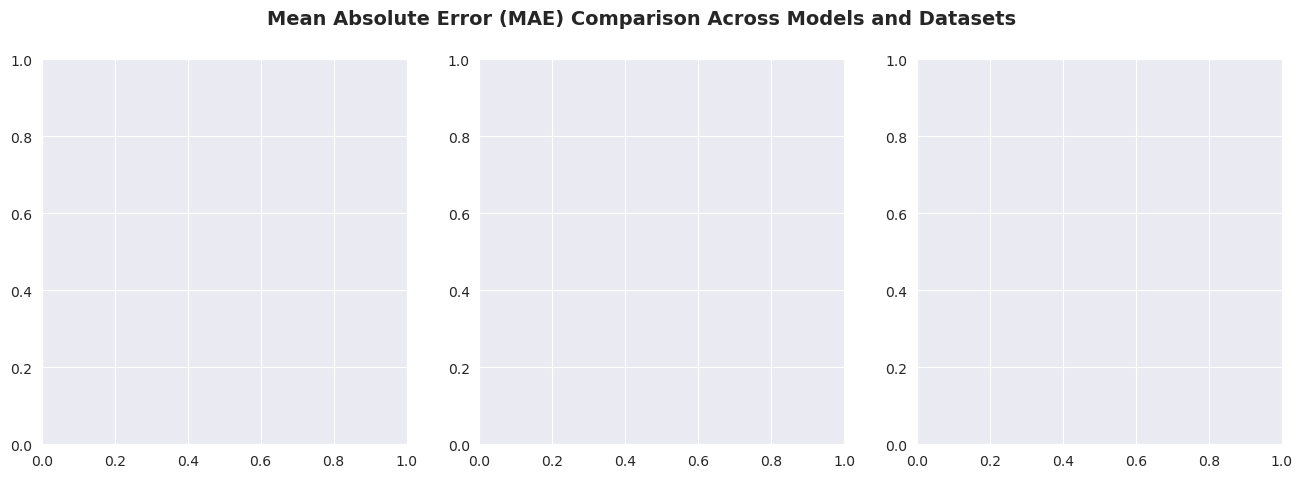

In [ ]:
# Prediction vs Actual Scatter Plots
for ext_ds in external_datasets:
    if ext_ds not in all_results:
        continue
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 13))
    fig.suptitle(f'{ext_ds.upper()} Dataset: Prediction vs Actual (Val+Test)', fontsize=16, fontweight='bold')
    
    models = list(all_results[ext_ds].keys())
    
    for row, param, param_name, lims in [(0, 0, 'dH', [-60, 0]), 
                                           (1, 1, 'Tm', [10, 80]),
                                           (2, None, 'dG₃₇', [-10, 10])]:
        for col, model in enumerate(models):
            ax = axes[row, col]
            results = all_results[ext_ds][model]
            
            if param is not None:
                y_true = results['y'][:, param]
                y_pred = results['pred'][:, param]
                metrics = results[param_name]
            else:
                y_true = calc_dG37(results['y'][:, 0], results['y'][:, 1])
                y_pred = calc_dG37(results['pred'][:, 0], results['pred'][:, 1])
                metrics = compute_metrics(y_true, y_pred)
            
            # Remove NaNs
            mask = ~(np.isnan(y_true) | np.isnan(y_pred))
            if len(y_true) > 0:
                y_true_clean = y_true[mask]
                y_pred_clean = y_pred[mask]
            else:
                y_true_clean = np.array([])
                y_pred_clean = np.array([])
            
            if len(y_true_clean) > 0:
                ax.scatter(y_true_clean, y_pred_clean, alpha=0.4, s=20, color='steelblue')
            
            ax.plot(lims, lims, 'r--', alpha=0.5, linewidth=2)
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            ax.set_xlabel(f'Measured {param_name}', fontsize=10)
            ax.set_ylabel(f'Predicted {param_name}', fontsize=10)
            
            title = f'{model}\nMAE={metrics["mae"]:.3f}, R²={metrics["r2"]:.3f}'
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Metric comparison bar plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Absolute Error (MAE) Comparison Across Models and Datasets', fontsize=14, fontweight='bold')

metrics_to_plot = ['dH', 'Tm', 'dG₃₇']
colors = {'GNN': 'steelblue', '1D_CNN': 'darkorange', '2D_CNN': 'seagreen'}

for ax, param in zip(axes.flatten(), metrics_to_plot):
    param_df = summary_df[summary_df['Parameter'] == param]
    
    # Pivot for plotting
    pivot_df = param_df.pivot(index='Model', columns='Dataset', values='MAE')
    pivot_df = pivot_df.reindex(['GNN', '1D_CNN', '2D_CNN'])
    
    pivot_df.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(f'{param} MAE', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('MAE', fontsize=11)
    ax.legend(title='Dataset', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# R² comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('R² Score Comparison Across Models and Datasets', fontsize=14, fontweight='bold')

for ax, param in zip(axes.flatten(), metrics_to_plot):
    param_df = summary_df[summary_df['Parameter'] == param]
    
    # Pivot for plotting
    pivot_df = param_df.pivot(index='Model', columns='Dataset', values='R²')
    pivot_df = pivot_df.reindex(['GNN', '1D_CNN', '2D_CNN'])
    
    pivot_df.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(f'{param} R²', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('R²', fontsize=11)
    ax.legend(title='Dataset', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print('\nVisualizations complete!')

## 9. Notes and Conclusions

### Evaluation Details
- **Datasets Evaluated**: ov (2775), uv (19), lit_uv (348) - external/unpublished datasets
- **Splits Used**: Combined validation + test splits for each external dataset
- **Normalization**: All metrics reported in unnormalized (original) space using training statistics
- **Predictions Made**: dH, Tm, and derived dG₃₇ (dG at 37°C)

### Metrics Reported
1. **MAE** (Mean Absolute Error): Average absolute difference in original units
2. **RMSE** (Root Mean Squared Error): Square root of average squared differences
3. **R²** (Coefficient of Determination): Proportion of variance explained (0=worst, 1=perfect)
4. **Bias**: Mean prediction error (positive = overprediction, negative = underprediction)

### Model Architectures
- **GNN**: Graph Neural Network with TransformerConv layers + Set2Set pooling
- **1D CNN**: Convolutional neural network operating on sequence + structure features (7 channels × 24 positions)
- **2D CNN**: 2D convolution on folded ladder representation (6 channels × 3×13 image)

### Data Encoding
Each model uses its own representative encoding:
- **GNN**: Graph representation (nodes as nucleotides, edges for backbone + hydrogen bonds)
- **1D CNN**: 1D tensor with sequence one-hot + structure encoding
- **2D CNN**: 2D folded ladder image with nucleotide and pairing information

---
Generated by Model Evaluation Notebook